# Electricity Load Forecasting - Comprehensive EDA
**Dataset:** `final_training_set_v1.csv`  
**Coverage:** Turkey national grid, Jan 2018 – Mar 2025  
**Project:** Ramadan-Aware STLF Benchmarking

---
### Notebook Structure
1. Setup & Load  
2. Dataset Overview  
3. Target Variable: Load Distribution & Stationarity  
4. Temporal Patterns (hour / DoW / month / year)  
5. Ramadan & Hijri Regime Analysis  
6. Weather–Load Relationships  
7. Heatwave Regime Analysis  
8. Compound Regime: Ramadan × Heatwave  
9. Feature Correlation & Multicollinearity  
10. Lag & Autocorrelation Analysis  
11. Data Quality Audit  
12. Summary & Modelling Implications

---
## 1. Setup & Load

In [395]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from pathlib import Path

# Palette
C_BLUE   = '#64b5f6'
C_ORANGE = '#ffb74d'
C_GREEN  = '#81c784'
C_RED    = '#e57373'
C_PURPLE = '#ba68c8'
C_TEAL   = '#4dd0e1'
REGIME_COLORS = {
    'Normal':   C_BLUE,
    'Ramadan':  C_ORANGE,
    'Heatwave': C_RED,
    'Compound': C_PURPLE,
}

print('Libraries loaded.')

Libraries loaded.


In [396]:
ROOT_DIR = Path().resolve().parents[0]
CSV_PATH = ROOT_DIR / 'data' / 'processed' / 'final_training_set_v1.csv'

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.set_index('timestamp').sort_index()

# ── Regime labels (mirrors evaluation protocol in proposal) ────────────────
# 95th percentile of daily max temperature (proxy series)
daily_max  = df.groupby(df.index.date)['temp_c'].max()
HW_THRESH  = daily_max.quantile(0.95)
print(f'Heatwave threshold (P95 daily max): {HW_THRESH:.2f}°C')

is_hot_day  = daily_max >= HW_THRESH
hot_day_map = {d: int(v) for d, v in is_hot_day.items()}

df['is_heatwave'] = [hot_day_map.get(ts.date(), 0) for ts in df.index]

print(f"Heatwave hours : {df['is_heatwave'].sum():,}  ({df['is_heatwave'].mean()*100:.1f}%)")
print(df.groupby(df.index.month)['is_heatwave'].mean().round(3))

def regime(row):
    if row['is_ramadan'] and row['is_heatwave']:
        return 'Compound'
    elif row['is_ramadan']:
        return 'Ramadan'
    elif row['is_heatwave']:
        return 'Heatwave'
    return 'Normal'

df['regime'] = df.apply(regime, axis=1)
print(df['regime'].value_counts())

# Convenience slices
TRAIN = df.loc['2018':'2022']
VAL   = df.loc['2023']
TEST  = df.loc['2024':'2025-03']

print(f'Loaded: {len(df):,} rows | {df.columns.tolist()}')
print(f'Date range: {df.index[0]} → {df.index[-1]}')
print(f'\nSplit sizes — Train: {len(TRAIN):,} | Val: {len(VAL):,} | Test: {len(TEST):,}')

Heatwave threshold (P95 daily max): 31.75°C
Heatwave hours : 3,528  (5.0%)
timestamp
1     0.000
2     0.000
3     0.000
4     0.000
5     0.000
6     0.046
7     0.250
8     0.270
9     0.029
10    0.000
11    0.000
12    0.000
Name: is_heatwave, dtype: float64
regime
Normal      60909
Ramadan      5688
Heatwave     3528
Name: count, dtype: int64
Loaded: 70,125 rows | ['actual_load', 'is_ramadan', 'is_eid', 'day_of_ramadan', 'hour', 'day_of_week', 'month', 'load_lag_24h', 'load_lag_168h', 'load_rolling_mean_24h', 'load_rolling_std_24h', 'load_rolling_mean_168h', 'load_rolling_std_168h', 'temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad', 'is_heatwave', 'regime']
Date range: 2018-01-01 00:00:00+00:00 → 2025-12-31 20:00:00+00:00

Split sizes — Train: 43,824 | Val: 8,760 | Test: 10,944


---
## 2. Dataset Overview

In [397]:
print('=== SCHEMA ===')
print(df.dtypes.to_string())
print(f'\n=== SHAPE: {df.shape} ===')

=== SCHEMA ===
actual_load               float64
is_ramadan                  int64
is_eid                      int64
day_of_ramadan              int64
hour                        int64
day_of_week                 int64
month                       int64
load_lag_24h              float64
load_lag_168h             float64
load_rolling_mean_24h     float64
load_rolling_std_24h      float64
load_rolling_mean_168h    float64
load_rolling_std_168h     float64
temp_c                    float64
dewpoint_c                float64
wind_speed                float64
solar_rad                 float64
is_heatwave                 int64
regime                     object

=== SHAPE: (70125, 19) ===


In [398]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
actual_load,70125.0,36283.196,6263.382,15333.300,31598.830,36046.180,40496.140,59503.670
is_ramadan,70125.0,0.081,0.273,0.000,0.000,0.000,0.000,1.000
is_eid,70125.0,0.008,0.090,0.000,0.000,0.000,0.000,1.000
day_of_ramadan,70125.0,1.242,4.839,0.000,0.000,0.000,0.000,30.000
hour,70125.0,11.500,6.922,0.000,5.000,11.000,17.000,23.000
day_of_week,70125.0,2.998,2.000,0.000,1.000,3.000,5.000,6.000
month,70125.0,6.523,3.449,1.000,4.000,7.000,10.000,12.000
load_lag_24h,70125.0,36278.943,6263.457,15333.300,31594.510,36042.620,40491.440,59503.670
load_lag_168h,70125.0,36264.826,6256.087,15333.300,31586.620,36035.900,40468.660,59503.670
load_rolling_mean_24h,70125.0,36280.839,4685.228,18350.172,33261.544,36171.337,38912.532,52019.225


In [399]:
# Regime composition
rc = df['regime'].value_counts()
print('=== Regime composition ===')
for r, n in rc.items():
    pct = n / len(df) * 100
    print(f'  {r:<12}: {n:>7,} hours  ({pct:.1f}%)')

=== Regime composition ===
  Normal      :  60,909 hours  (86.9%)
  Ramadan     :   5,688 hours  (8.1%)
  Heatwave    :   3,528 hours  (5.0%)


---
## 3. Target Variable: Load Distribution & Stationarity

Text(0, 0.5, 'MW')

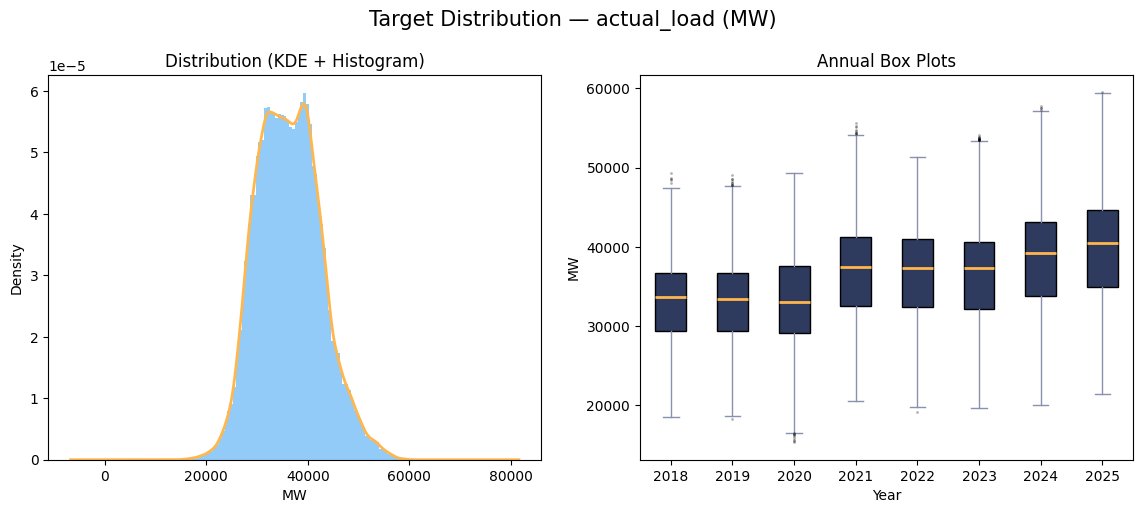

In [400]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Distribution — actual_load (MW)', fontsize=15, y=1.01)

# Histogram + KDE
ax = axes[0]
df['actual_load'].hist(bins=80, color=C_BLUE, alpha=0.7, ax=ax, density=True)
df['actual_load'].plot.kde(ax=ax, color=C_ORANGE, lw=2)
ax.set_title('Distribution (KDE + Histogram)')
ax.set_xlabel('MW')

# Box by year
ax = axes[1]
yearly = [df.loc[str(y), 'actual_load'].values for y in range(2018, 2026)]
bp = ax.boxplot(yearly, patch_artist=True,
                medianprops=dict(color=C_ORANGE, lw=2),
                whiskerprops=dict(color='#8892b0'),
                capprops=dict(color='#8892b0'),
                flierprops=dict(marker='.', color=C_RED, alpha=0.3, markersize=2))
for patch in bp['boxes']:
    patch.set_facecolor('#2e3a5e')
ax.set_xticklabels(range(2018, 2026))
ax.set_title('Annual Box Plots')
ax.set_xlabel('Year')
ax.set_ylabel('MW')


In [401]:
# Stationarity tests
print('=== Augmented Dickey-Fuller (H0: unit root) ===')
adf_stat, adf_p, _, _, adf_cv, _ = adfuller(df['actual_load'].dropna(), autolag='AIC')
print(f'  ADF stat : {adf_stat:.4f}')
print(f'  p-value  : {adf_p:.6f}')
print(f'  Critical : {adf_cv}')
print(f'  Result   : {"STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"} at 5%')

print('\n=== KPSS (H0: stationary) ===')
kpss_stat, kpss_p, _, kpss_cv = kpss(df['actual_load'].dropna(), regression='c')
print(f'  KPSS stat: {kpss_stat:.4f}')
print(f'  p-value  : {kpss_p:.6f}')
print(f'  Critical : {kpss_cv}')
print(f'  Result   : {"STATIONARY" if kpss_p > 0.05 else "NON-STATIONARY"} at 5%')

=== Augmented Dickey-Fuller (H0: unit root) ===
  ADF stat : -11.9285
  p-value  : 0.000000
  Critical : {'1%': np.float64(-3.430443339322371), '5%': np.float64(-2.8615812543238897), '10%': np.float64(-2.5667919582668643)}
  Result   : STATIONARY at 5%

=== KPSS (H0: stationary) ===
  KPSS stat: 19.3482
  p-value  : 0.010000
  Critical : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  Result   : NON-STATIONARY at 5%


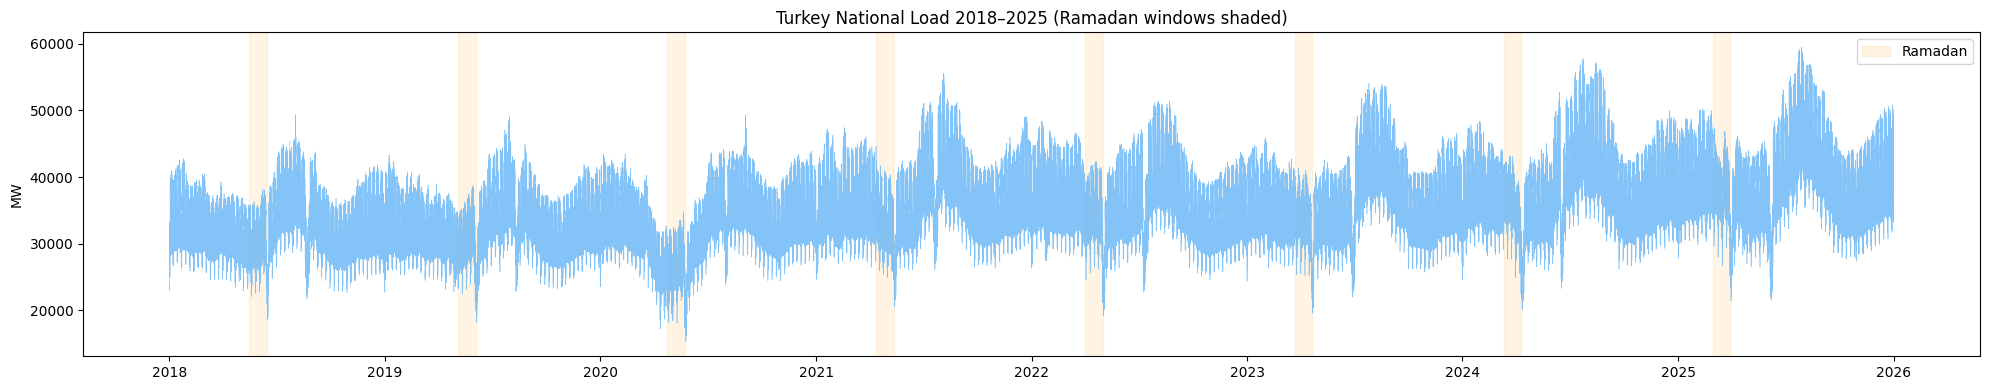

In [402]:
# Full time series
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df.index, df['actual_load'], color=C_BLUE, lw=0.4, alpha=0.8)
# Shade Ramadan windows
in_ramadan = False
start = None
for ts, val in df['is_ramadan'].items():
    if val == 1 and not in_ramadan:
        start = ts; in_ramadan = True
    elif val == 0 and in_ramadan:
        ax.axvspan(start, ts, alpha=0.15, color=C_ORANGE, label='Ramadan' if start == df[df['is_ramadan']==1].index[0] else '')
        in_ramadan = False
ax.set_title('Turkey National Load 2018–2025 (Ramadan windows shaded)')
ax.set_ylabel('MW')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Temporal Patterns

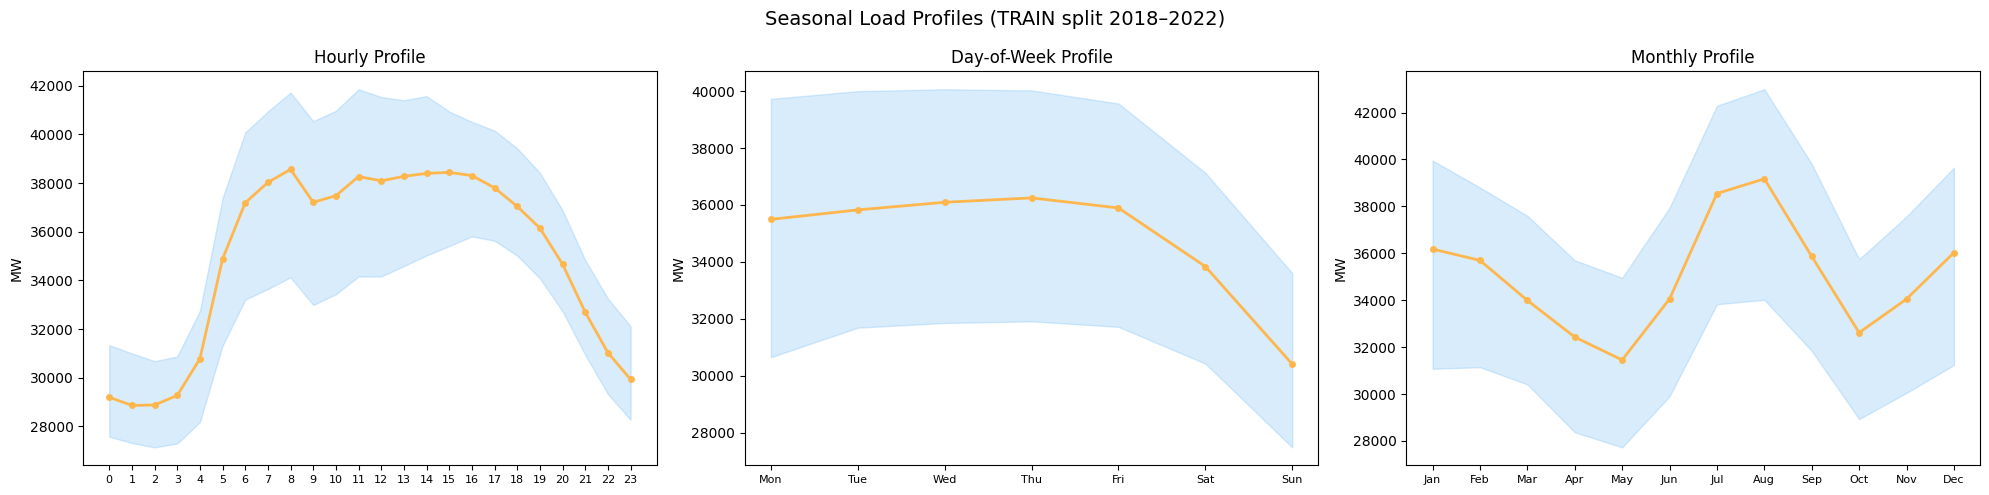

In [403]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Seasonal Load Profiles (TRAIN split 2018–2022)', fontsize=14)

labels_hour = list(range(24))
labels_dow  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
labels_mon  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, groupby, labels, title in zip(
    axes,
    [TRAIN.index.hour, TRAIN.index.dayofweek, TRAIN.index.month],
    [labels_hour, labels_dow, labels_mon],
    ['Hourly Profile', 'Day-of-Week Profile', 'Monthly Profile']
):
    grp = TRAIN.groupby(groupby)['actual_load']
    med = grp.median()
    q25 = grp.quantile(0.25)
    q75 = grp.quantile(0.75)
    x   = np.arange(len(med))
    ax.fill_between(x, q25, q75, alpha=0.25, color=C_BLUE)
    ax.plot(x, med, color=C_ORANGE, lw=2, marker='o', markersize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('MW')

plt.tight_layout()
plt.show()

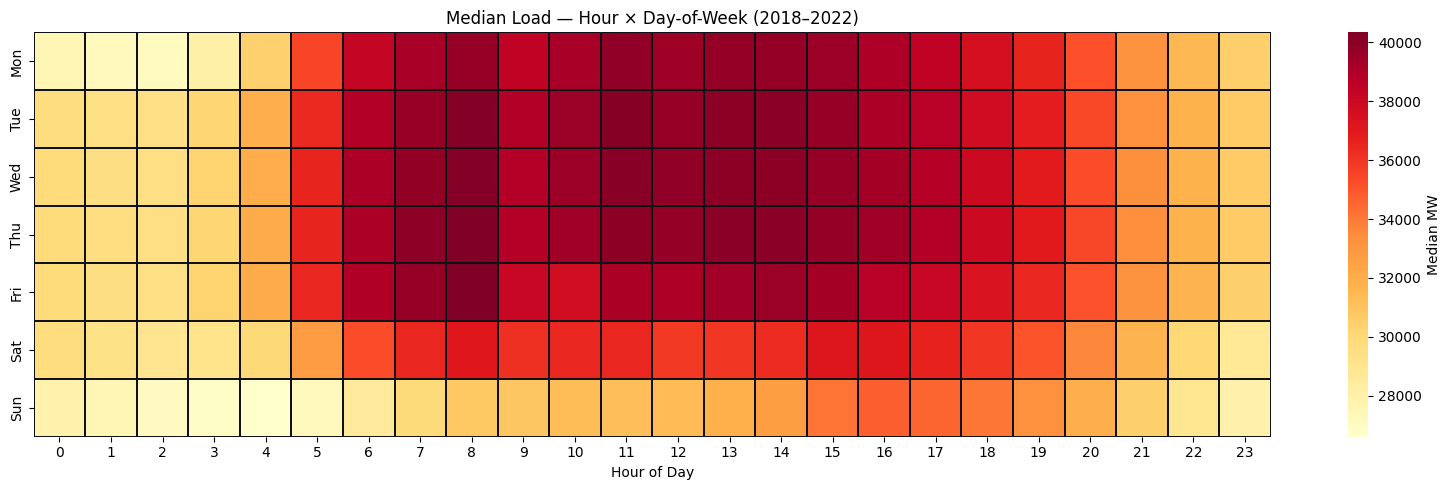

In [404]:
# Heatmap: hour × day-of-week
pivot_hw = TRAIN.groupby([TRAIN.index.dayofweek, TRAIN.index.hour])['actual_load'].median().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_hw,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#0f1117',
    yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    cbar_kws={'label': 'Median MW'}
)
ax.set_title('Median Load — Hour × Day-of-Week (2018–2022)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

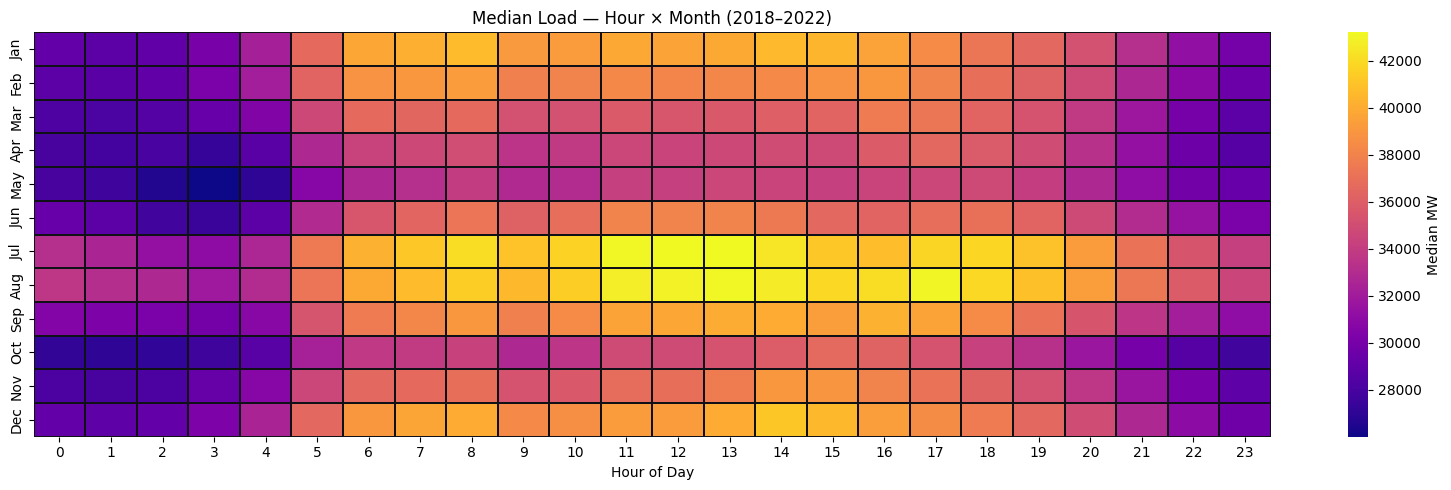

In [405]:
# Heatmap: hour × month
pivot_hm = TRAIN.groupby([TRAIN.index.month, TRAIN.index.hour])['actual_load'].median().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_hm,
    ax=ax,
    cmap='plasma',
    linewidths=0.3,
    linecolor='#0f1117',
    yticklabels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    cbar_kws={'label': 'Median MW'}
)
ax.set_title('Median Load — Hour × Month (2018–2022)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

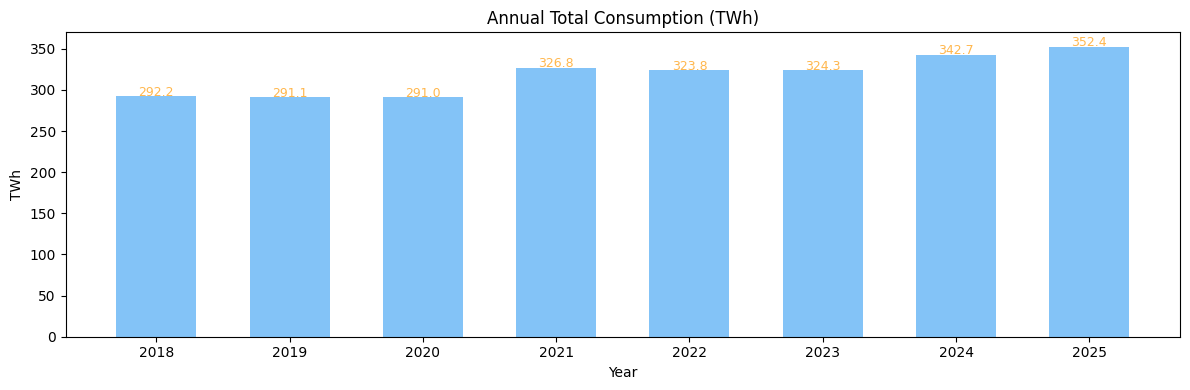

Year-on-Year growth (%):
timestamp
2019-12-31 00:00:00+00:00    -0.40
2020-12-31 00:00:00+00:00    -0.02
2021-12-31 00:00:00+00:00    12.29
2022-12-31 00:00:00+00:00    -0.92
2023-12-31 00:00:00+00:00     0.16
2024-12-31 00:00:00+00:00     5.67
2025-12-31 00:00:00+00:00     2.84
Freq: YE-DEC


In [406]:
# YoY growth — annual totals
annual = df.resample('YE')['actual_load'].sum() / 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annual.index.year, annual.values, color=C_BLUE, alpha=0.8, width=0.6)
for y, v in zip(annual.index.year, annual.values):
    ax.text(y, v + 0.5, f'{v:.1f}', ha='center', fontsize=9, color=C_ORANGE)
ax.set_title('Annual Total Consumption (TWh)')
ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.set_xticks(annual.index.year)
plt.tight_layout()
plt.show()

growth = annual.pct_change() * 100
print('Year-on-Year growth (%):')
print(growth.dropna().round(2).to_string())

---
## 5. Ramadan & Hijri Regime Analysis

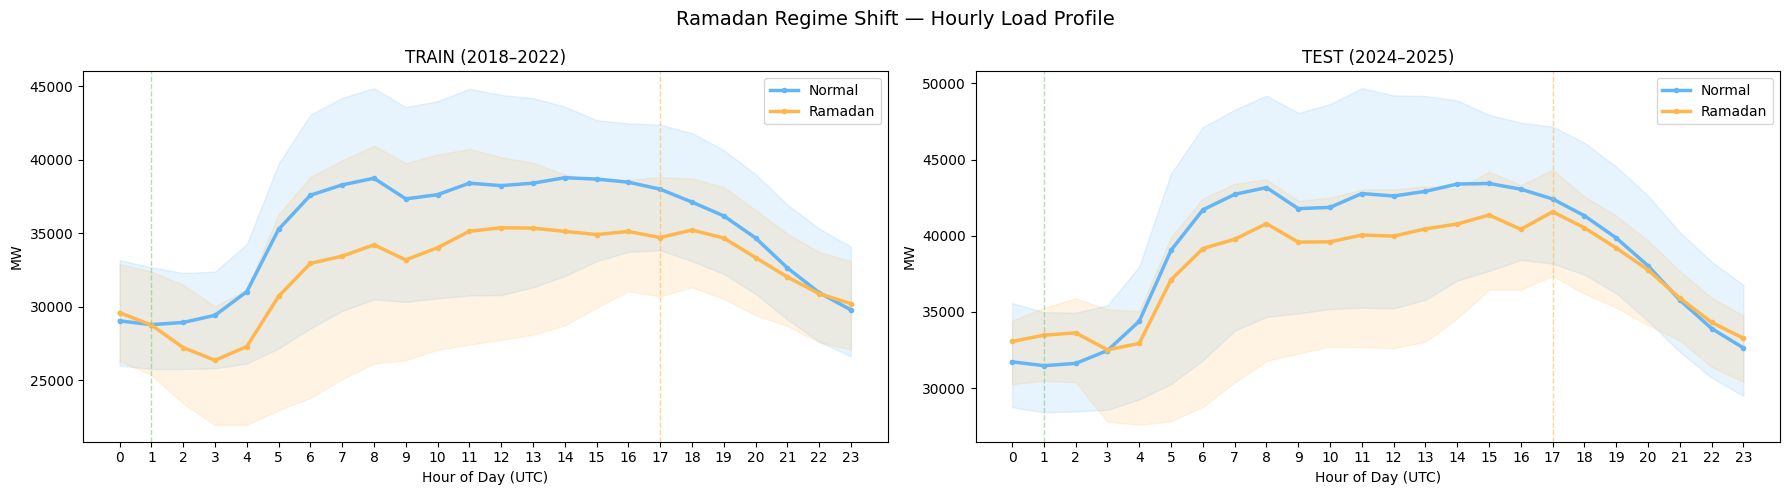

In [407]:
# Ramadan vs Normal hourly profile overlay
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Ramadan Regime Shift — Hourly Load Profile', fontsize=14)

for ax, split_name, split_df in [('left', 'TRAIN (2018–2022)', TRAIN), ('right', 'TEST (2024–2025)', TEST)]:
    ax = axes[0] if split_name.startswith('TRAIN') else axes[1]
    for regime_name, color in [('Normal', C_BLUE), ('Ramadan', C_ORANGE)]:
        sub = split_df[split_df['regime'] == regime_name]
        grp = sub.groupby(sub.index.hour)['actual_load']
        med = grp.median()
        q25 = grp.quantile(0.1)
        q75 = grp.quantile(0.9)
        ax.fill_between(range(24), q25, q75, alpha=0.15, color=color)
        ax.plot(range(24), med, color=color, lw=2.5, label=regime_name, marker='o', markersize=3)
    ax.set_xticks(range(24))
    ax.set_title(f'{split_name}')
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('MW')
    ax.legend()
    # Mark iftar (~17:00 UTC = 20:00 Istanbul) and suhoor (~01:00 UTC)
    ax.axvline(17, color=C_ORANGE, ls='--', lw=1, alpha=0.6, label='Iftar ~UTC17')
    ax.axvline(1,  color=C_GREEN,  ls='--', lw=1, alpha=0.6, label='Suhoor ~UTC01')

plt.tight_layout()
plt.show()

In [408]:
# Load delta: Ramadan vs matched non-Ramadan windows (same month, same DoW)
print('=== Load shift: Ramadan vs Non-Ramadan (MW) ===')
ram  = df[df['is_ramadan'] == 1]['actual_load']
norm = df[df['is_ramadan'] == 0]['actual_load']

print(f'  Non-Ramadan median : {norm.median():,.0f} MW')
print(f'  Ramadan median     : {ram.median():,.0f} MW')
print(f'  Delta              : {ram.median() - norm.median():+,.0f} MW  ({(ram.median()/norm.median()-1)*100:+.2f}%)')

t_stat, p_val = stats.ttest_ind(ram.dropna(), norm.dropna(), equal_var=False)
print(f'\n  Welch t-test: t={t_stat:.2f}, p={p_val:.2e} → {"SIGNIFICANT" if p_val<0.05 else "NOT significant"}')

=== Load shift: Ramadan vs Non-Ramadan (MW) ===
  Non-Ramadan median : 36,318 MW
  Ramadan median     : 33,677 MW
  Delta              : -2,642 MW  (-7.27%)

  Welch t-test: t=-40.84, p=0.00e+00 → SIGNIFICANT


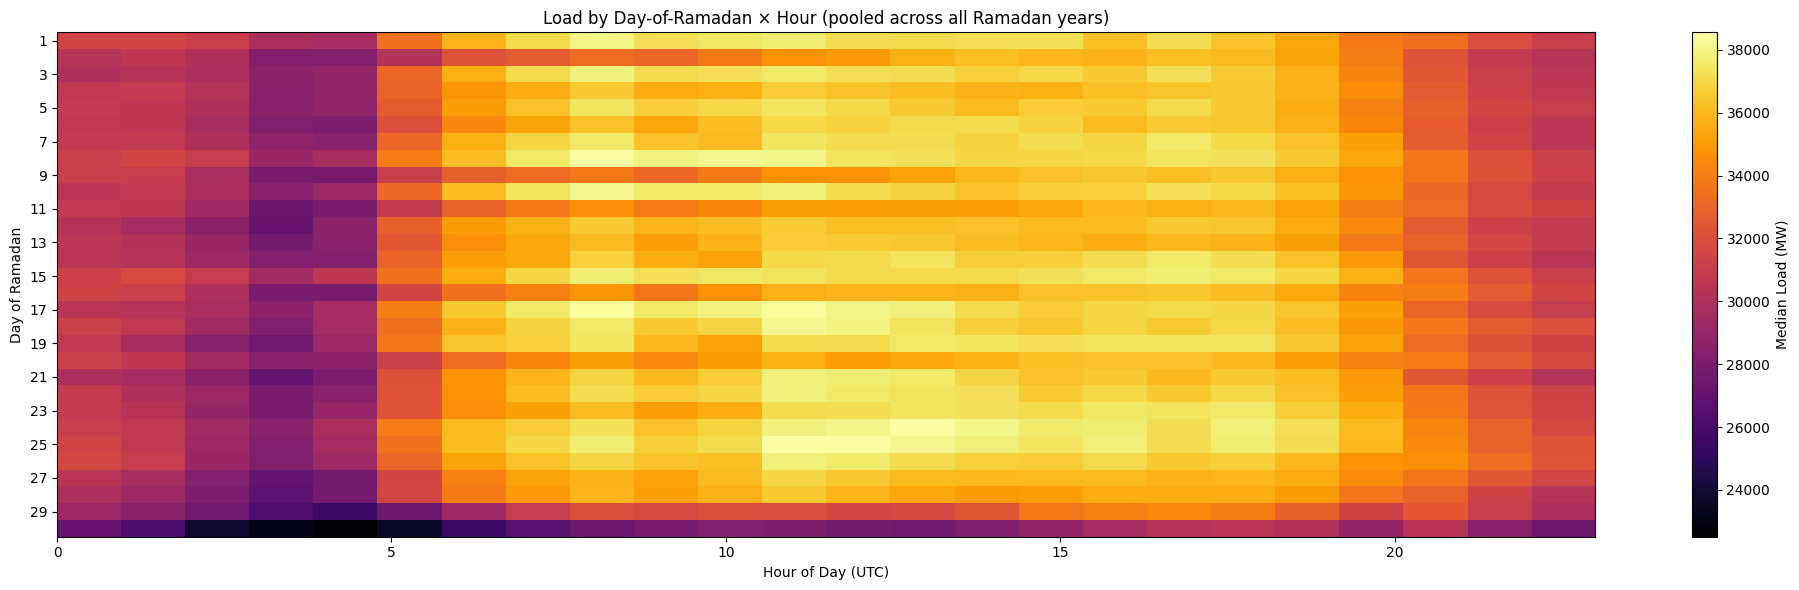

In [409]:
# Day-of-Ramadan progression (days 1–30)
ram_df = df[df['is_ramadan'] == 1].copy()
dor_profile = ram_df.groupby(['day_of_ramadan', ram_df.index.hour])['actual_load'].median().unstack()

fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(dor_profile.values, aspect='auto', cmap='inferno',
               extent=[0, 23, 30.5, 0.5])
plt.colorbar(im, ax=ax, label='Median Load (MW)')
ax.set_title('Load by Day-of-Ramadan × Hour (pooled across all Ramadan years)')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Day of Ramadan')
ax.set_yticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

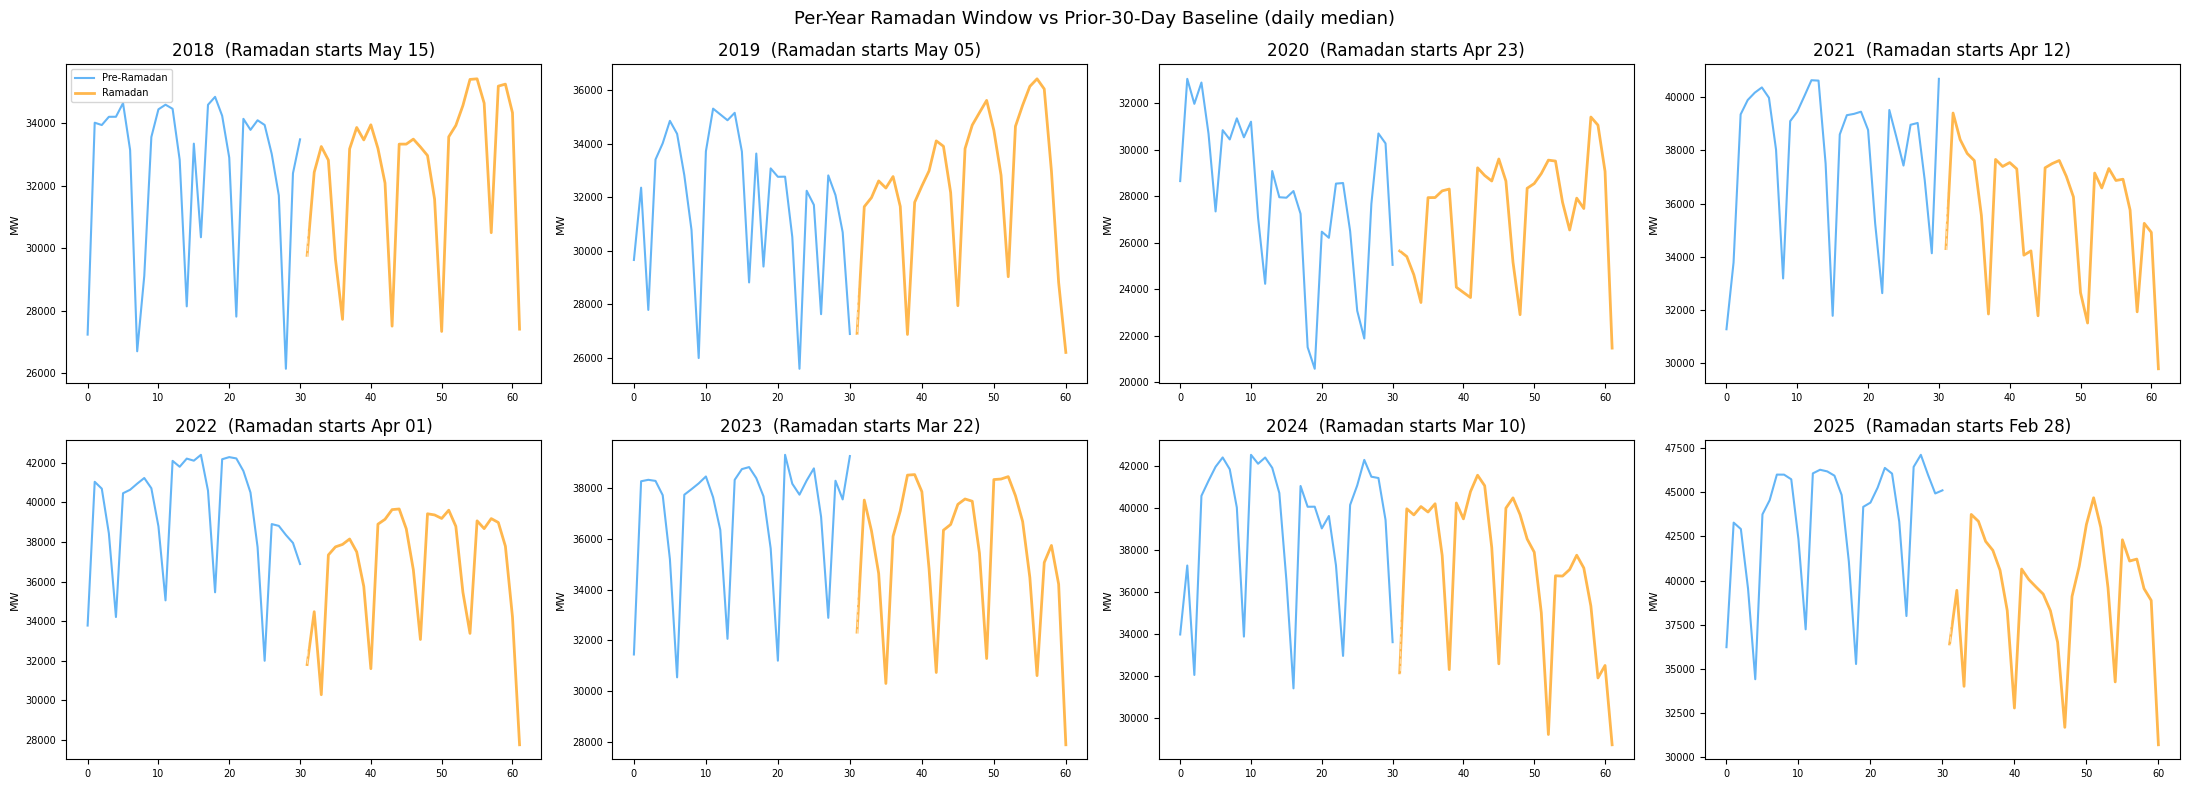

In [410]:
# Per-year Ramadan windows — load vs prior 30-day baseline
fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharex=False, sharey=False)
fig.suptitle('Per-Year Ramadan Window vs Prior-30-Day Baseline (daily median)', fontsize=13)
axes = axes.flatten()

for i, year in enumerate(range(2018, 2026)):
    ax = axes[i]
    year_df = df.loc[str(year)]
    ram_days = year_df[year_df['is_ramadan'] == 1]
    if len(ram_days) == 0:
        ax.set_visible(False); continue

    ram_start = ram_days.index[0]
    pre_start = ram_start - pd.Timedelta(days=30)
    pre_days  = df[pre_start:ram_start - pd.Timedelta(hours=1)]

    ram_daily = ram_days.resample('D')['actual_load'].median()
    pre_daily = pre_days.resample('D')['actual_load'].median()

    ax.plot(range(len(pre_daily)), pre_daily.values, color=C_BLUE,   lw=1.5, label='Pre-Ramadan')
    ax.plot(range(len(pre_daily), len(pre_daily)+len(ram_daily)),
            ram_daily.values, color=C_ORANGE, lw=2,   label='Ramadan')
    ax.axvline(len(pre_daily), color='white', ls='--', lw=1, alpha=0.5)
    ax.set_title(f'{year}  (Ramadan starts {ram_start.strftime("%b %d")})')
    ax.set_ylabel('MW', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

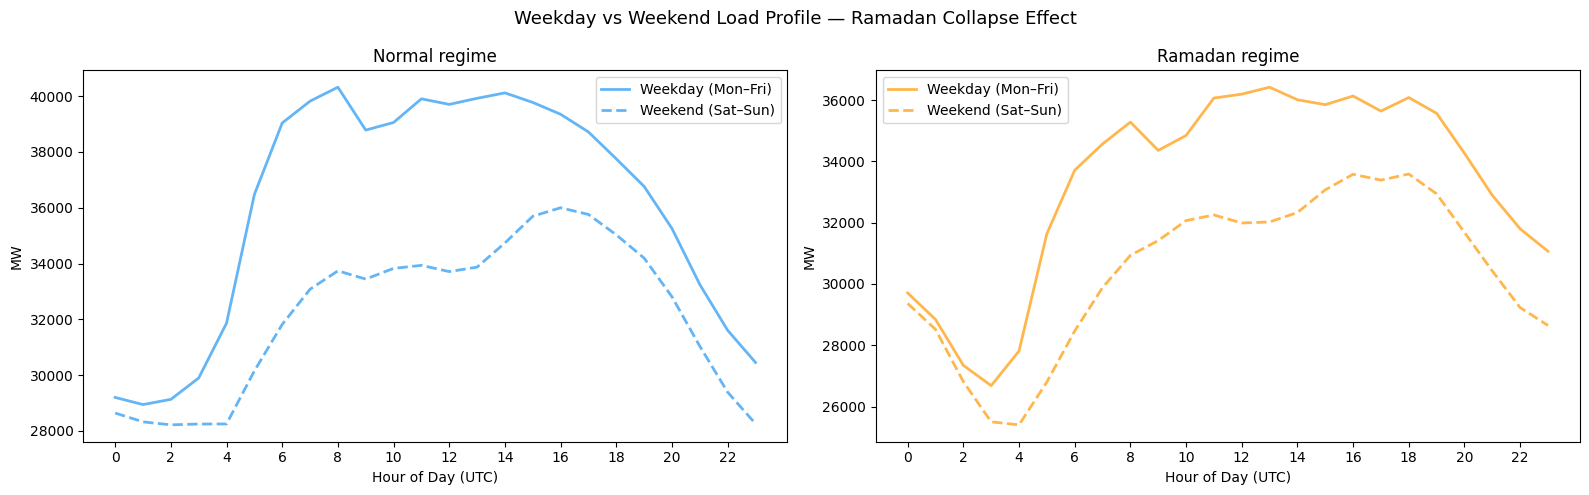

Normal    : weekday=36,109 MW | weekend=32,085 MW | ratio=0.889
Ramadan   : weekday=33,332 MW | weekend=30,091 MW | ratio=0.903


In [411]:
# Weekday/weekend collapse during Ramadan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Weekday vs Weekend Load Profile — Ramadan Collapse Effect', fontsize=13)

for ax, regime_name, color in [(axes[0], 'Normal', C_BLUE), (axes[1], 'Ramadan', C_ORANGE)]:
    sub = TRAIN[TRAIN['regime'] == regime_name]
    for dow_label, dow_mask, ls in [
        ('Weekday (Mon–Fri)', sub.index.dayofweek < 5, '-'),
        ('Weekend (Sat–Sun)', sub.index.dayofweek >= 5, '--'),
    ]:
        grp = sub[dow_mask].groupby(sub[dow_mask].index.hour)['actual_load'].median()
        ax.plot(range(24), grp.values, lw=2, ls=ls, color=color, label=dow_label)
    ax.set_title(f'{regime_name} regime')
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('MW')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()

plt.tight_layout()
plt.show()

# Quantify collapse: ratio of weekend/weekday median
for regime_name in ['Normal', 'Ramadan']:
    sub  = TRAIN[TRAIN['regime'] == regime_name]
    wday = sub[sub.index.dayofweek < 5]['actual_load'].median()
    wend = sub[sub.index.dayofweek >= 5]['actual_load'].median()
    print(f'{regime_name:<10}: weekday={wday:,.0f} MW | weekend={wend:,.0f} MW | ratio={wend/wday:.3f}')

---
## 6. Weather–Load Relationships

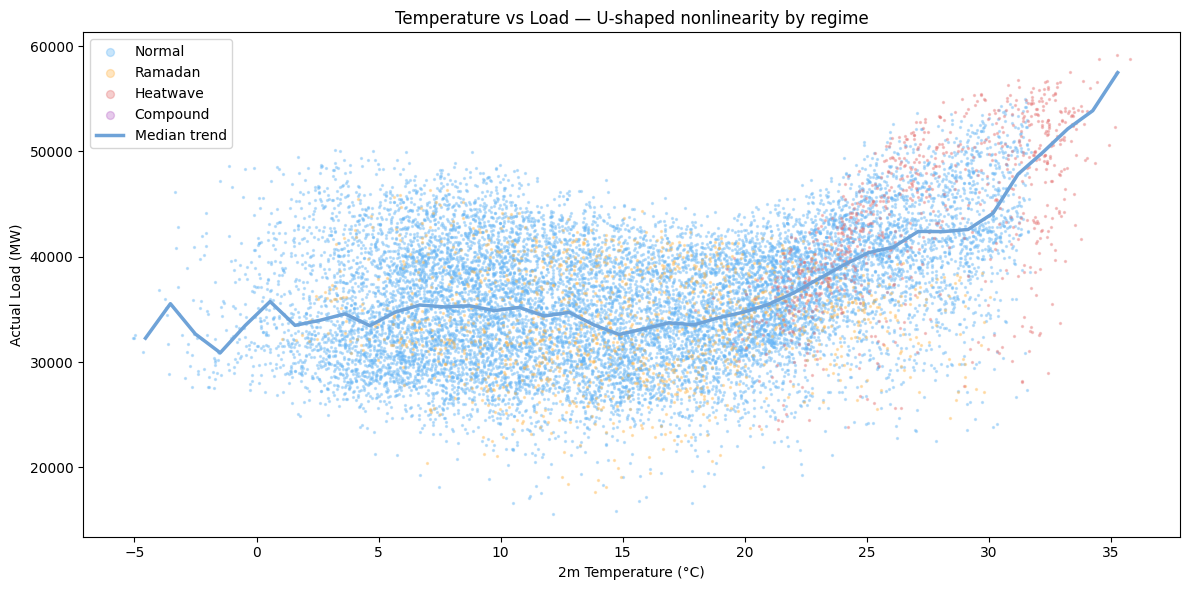

In [433]:
# Scatter: temperature vs load, coloured by regime
fig, ax = plt.subplots(figsize=(12, 6))
sample = df.sample(min(15000, len(df)), random_state=42)

for regime_name, color in REGIME_COLORS.items():
    sub = sample[sample['regime'] == regime_name]
    ax.scatter(sub['temp_c'], sub['actual_load'], s=2, alpha=0.35,
               color=color, label=regime_name, rasterized=True)

# Loess-style smooth for all data
from scipy.stats import binned_statistic
bin_means, bin_edges, _ = binned_statistic(sample['temp_c'], sample['actual_load'],
                                            statistic='median', bins=40)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, bin_means, color='#6FA3D8', lw=2.5, label='Median trend', zorder=5)

ax.set_xlabel('2m Temperature (°C)')
ax.set_ylabel('Actual Load (MW)')
ax.set_title('Temperature vs Load — U-shaped nonlinearity by regime')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

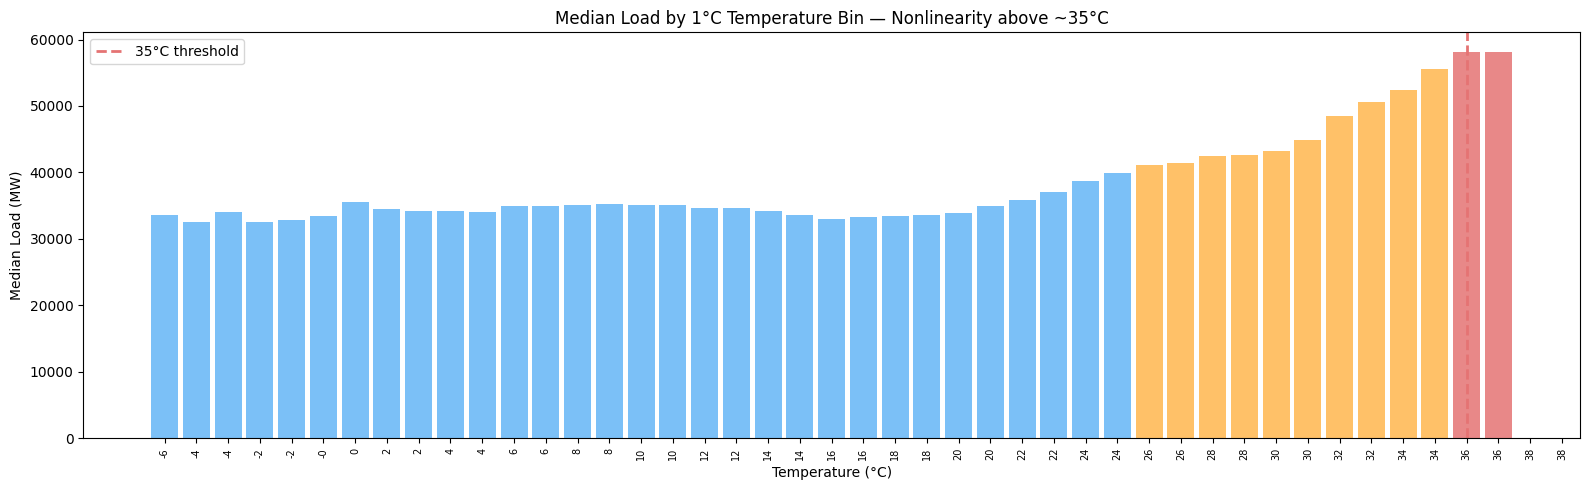

In [413]:
# Temperature threshold nonlinearity: load by 1°C bin
df['temp_bin'] = pd.cut(df['temp_c'], bins=range(-6, 40, 1))
temp_load = df.groupby('temp_bin')['actual_load'].median()

fig, ax = plt.subplots(figsize=(16, 5))
colors = [C_RED if b.mid >= 35 else C_ORANGE if b.mid >= 25 else C_BLUE
          for b in temp_load.index]
ax.bar(range(len(temp_load)), temp_load.values, color=colors, width=0.85, alpha=0.85)
ax.axvline(temp_load.index.get_loc(temp_load.index[temp_load.index.map(lambda b: b.mid >= 35)][0]),
           color=C_RED, ls='--', lw=2, label='35°C threshold')
ax.set_xticks(range(len(temp_load)))
ax.set_xticklabels([f'{b.mid:.0f}' for b in temp_load.index], rotation=90, fontsize=7)
ax.set_title('Median Load by 1°C Temperature Bin — Nonlinearity above ~35°C')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Median Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [414]:
# Weather variable correlations with load
weather_vars = ['temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad']
print('=== Pearson correlation with actual_load ===')
for v in weather_vars:
    r, p = stats.pearsonr(df[v].dropna(), df.loc[df[v].notna(), 'actual_load'])
    print(f'  {v:<15}: r={r:+.4f}  p={p:.2e}')

print('\n=== Spearman (rank) correlation with actual_load ===')
for v in weather_vars:
    r, p = stats.spearmanr(df[v].dropna(), df.loc[df[v].notna(), 'actual_load'])
    print(f'  {v:<15}: r={r:+.4f}  p={p:.2e}')

=== Pearson correlation with actual_load ===
  temp_c         : r=+0.3359  p=0.00e+00
  dewpoint_c     : r=+0.1452  p=0.00e+00
  wind_speed     : r=+0.1880  p=0.00e+00
  solar_rad      : r=+0.1528  p=0.00e+00

=== Spearman (rank) correlation with actual_load ===
  temp_c         : r=+0.2922  p=0.00e+00
  dewpoint_c     : r=+0.1382  p=4.22e-296
  wind_speed     : r=+0.1910  p=0.00e+00
  solar_rad      : r=+0.1829  p=0.00e+00


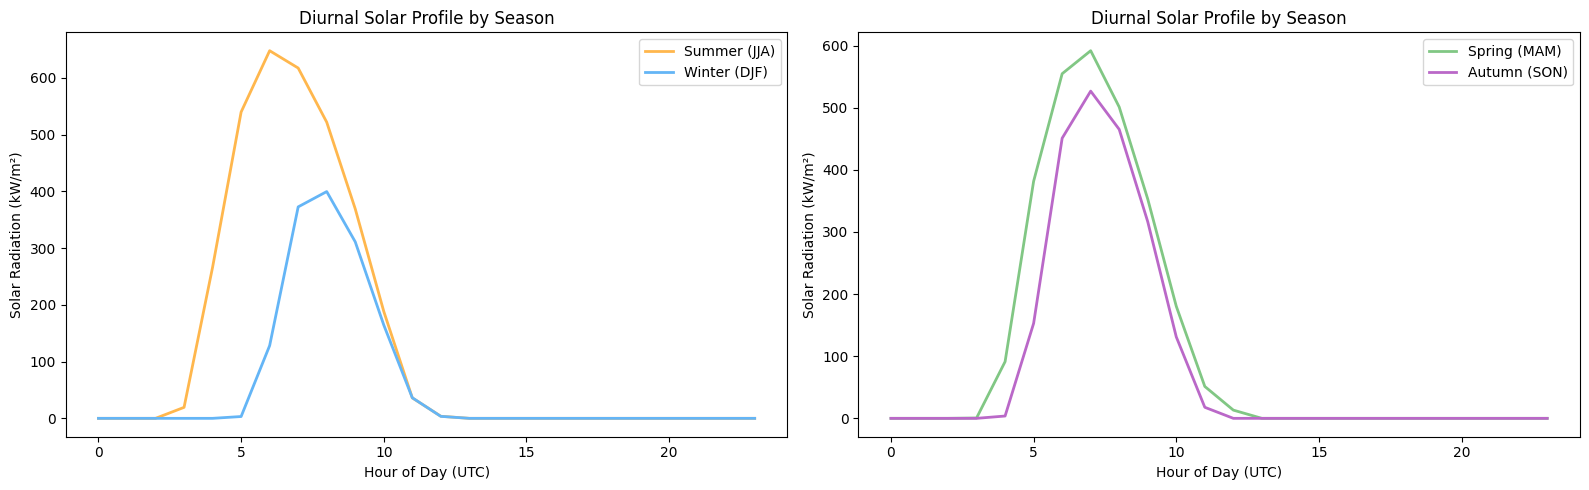

In [415]:
# Solar radiation diurnal pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, month_group, label, color in [
    (axes[0], [6, 7, 8], 'Summer (JJA)', C_ORANGE),
    (axes[0], [12, 1, 2], 'Winter (DJF)', C_BLUE),
    (axes[1], [3, 4, 5], 'Spring (MAM)', C_GREEN),
    (axes[1], [9, 10, 11], 'Autumn (SON)', C_PURPLE),
]:
    sub = df[df.index.month.isin(month_group)]
    grp = sub.groupby(sub.index.hour)['solar_rad'].median()
    ax.plot(range(24), grp.values / 1000, lw=2, label=label, color=color)

for ax in axes:
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('Solar Radiation (kW/m²)')
    ax.set_title('Diurnal Solar Profile by Season')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 7. Heatwave Regime Analysis

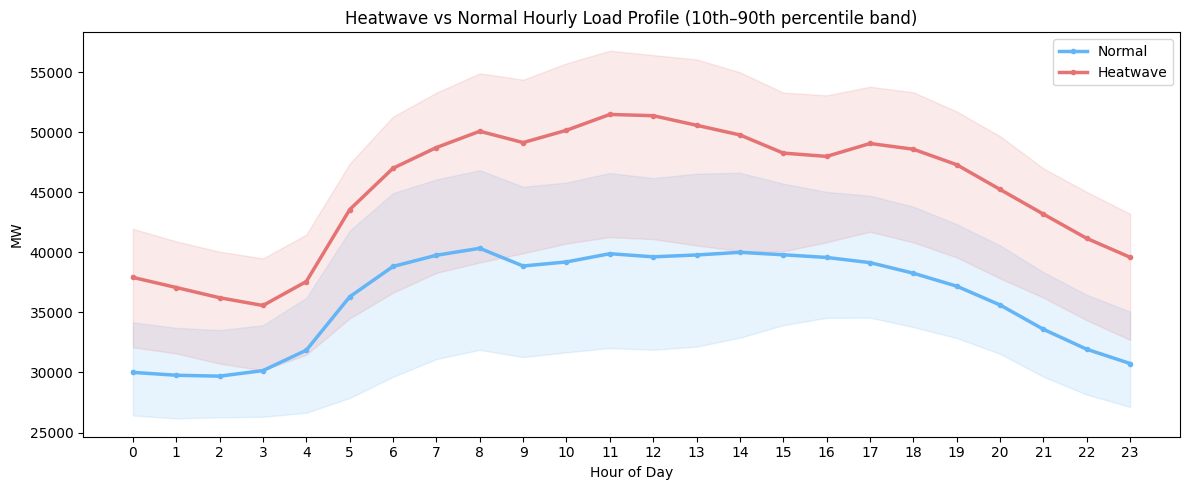

In [416]:
fig, ax = plt.subplots(figsize=(12, 5))

for regime_name, color in [('Normal', C_BLUE), ('Heatwave', C_RED)]:

    sub = df[df['regime'] == regime_name]

    grp = sub.groupby(sub.index.hour)['actual_load']

    med = grp.median().reindex(range(24))
    q10 = grp.quantile(0.1).reindex(range(24))
    q90 = grp.quantile(0.9).reindex(range(24))

    ax.fill_between(range(24), q10, q90,
                    alpha=0.15, color=color)

    ax.plot(range(24), med,
            color=color,
            lw=2.5,
            label=regime_name,
            marker='o',
            markersize=3)

ax.set_title('Heatwave vs Normal Hourly Load Profile (10th–90th percentile band)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('MW')
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

In [417]:
# Top-10 peak load days
daily_peak = df.groupby(df.index.date)['actual_load'].max().sort_values(ascending=False).head(10)
daily_peak_df = daily_peak.reset_index()
daily_peak_df.columns = ['date', 'peak_mw']
daily_peak_df['date'] = pd.to_datetime(daily_peak_df['date'])
daily_peak_df['month'] = daily_peak_df['date'].dt.month
daily_peak_df['regime'] = daily_peak_df['date'].apply(
    lambda d: df[df.index.date == d.date()]['regime'].iloc[0] if len(df[df.index.date == d.date()]) else 'Unknown'
)

print('=== Top-10 Peak Load Days ===')
print(daily_peak_df.to_string(index=False))

=== Top-10 Peak Load Days ===
      date  peak_mw  month   regime
2025-07-28 59503.67      7 Heatwave
2025-07-24 59168.57      7 Heatwave
2025-07-25 58998.99      7 Heatwave
2025-07-29 58823.58      7 Heatwave
2025-07-23 58751.46      7 Heatwave
2025-07-30 58514.44      7 Heatwave
2024-07-23 57772.40      7 Heatwave
2025-07-31 57612.75      7 Heatwave
2024-07-22 57473.33      7 Heatwave
2024-08-14 57198.59      8 Heatwave


---
## 8. Compound Regime: Ramadan × Heatwave

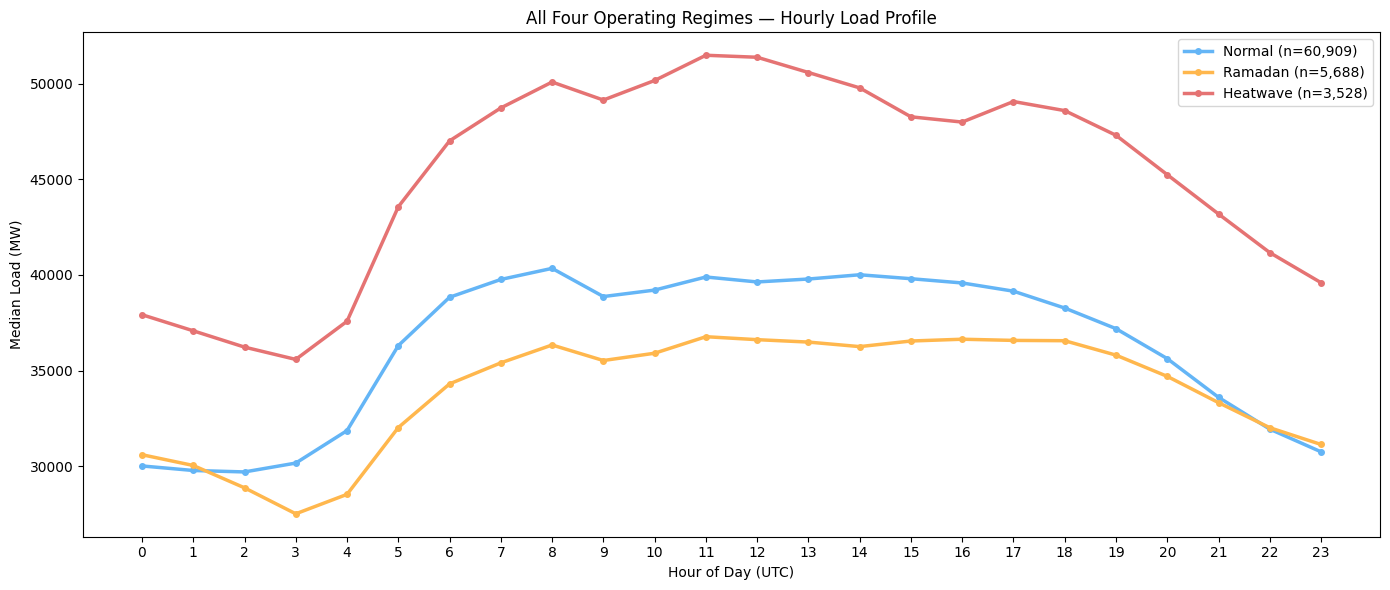

In [418]:
# All four regime hourly profiles on one chart
fig, ax = plt.subplots(figsize=(14, 6))
for regime_name, color in REGIME_COLORS.items():
    sub = df[df['regime'] == regime_name]
    if len(sub) == 0: continue
    grp = sub.groupby(sub.index.hour)['actual_load'].median()
    ax.plot(range(24), grp.values, color=color, lw=2.5, label=f'{regime_name} (n={len(sub):,})', marker='o', markersize=4)

ax.set_title('All Four Operating Regimes — Hourly Load Profile')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Median Load (MW)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

In [419]:
rows = []

for regime_name in ['Normal', 'Ramadan', 'Heatwave', 'Compound']:

    sub = df[df['regime'] == regime_name]['actual_load']

    rows.append({
        'Regime'    : regime_name,
        'N (hrs)'   : len(sub),
        'Mean MW'   : round(sub.mean(), 0),
        'Median MW' : round(sub.median(), 0),
        'Std MW'    : round(sub.std(), 0),
        'P5 MW'     : round(sub.quantile(0.05), 0),
        'P95 MW'    : round(sub.quantile(0.95), 0),
        'Max MW'    : round(sub.max(), 0),
    })

pd.DataFrame(rows).set_index('Regime')

,N (hrs),Mean MW,Median MW,Std MW,P5 MW,P95 MW,Max MW
Regime,,,,,,,
Normal,60909,36083.0,35961.0,5952.0,26969.0,46080.0,55726.0
Ramadan,5688,33594.0,33677.0,5071.0,25007.0,41350.0,47414.0
Heatwave,3528,44069.0,44162.0,7329.0,31709.0,55032.0,59504.0
Compound,0,NaN,NaN,NaN,NaN,NaN,NaN


---
## 9. Feature Correlation & Multicollinearity

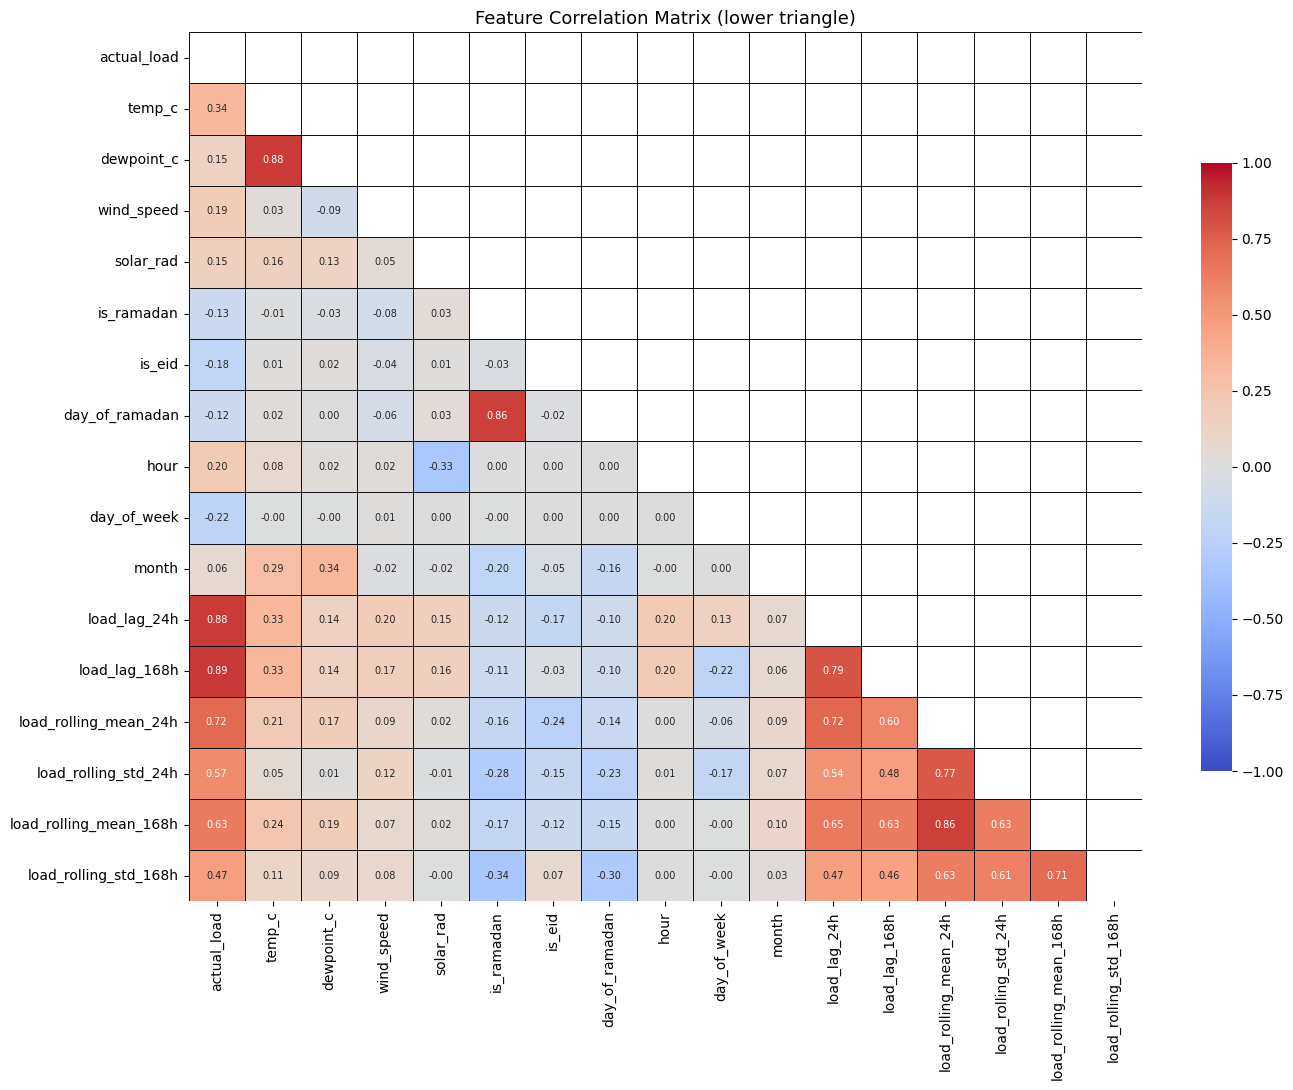

In [420]:
feat_cols = [
    'actual_load',
    'temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad',
    'is_ramadan', 'is_eid', 'day_of_ramadan',
    'hour', 'day_of_week', 'month',
    'load_lag_24h', 'load_lag_168h',
    'load_rolling_mean_24h', 'load_rolling_std_24h',
    'load_rolling_mean_168h', 'load_rolling_std_168h',
]
feat_cols = [c for c in feat_cols if c in df.columns]

corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='#0f1117',
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

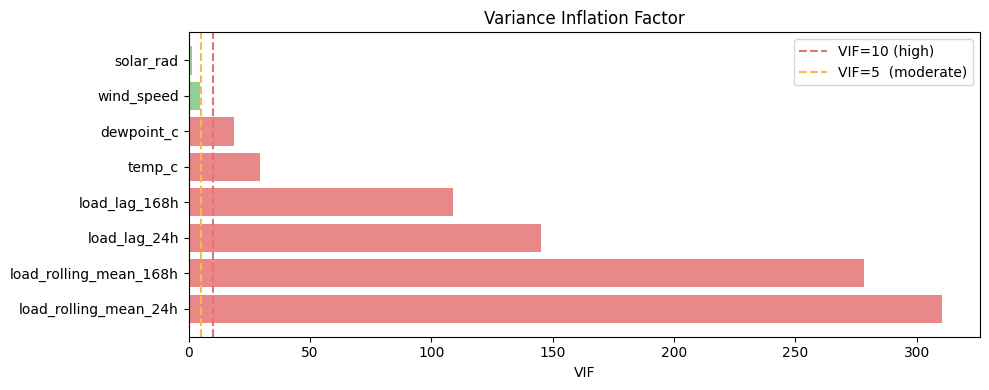

               Feature        VIF
 load_rolling_mean_24h 310.514029
load_rolling_mean_168h 278.192208
          load_lag_24h 144.985058
         load_lag_168h 108.737686
                temp_c  29.415135
            dewpoint_c  18.722976
            wind_speed   4.760647
             solar_rad   1.372136


In [421]:
# VIF for numeric features
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad',
            'load_lag_24h', 'load_lag_168h',
            'load_rolling_mean_24h', 'load_rolling_mean_168h']
vif_cols = [c for c in vif_cols if c in df.columns]

vif_data = df[vif_cols].dropna()
vif_vals = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif_df = pd.DataFrame({'Feature': vif_cols, 'VIF': vif_vals}).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [C_RED if v > 10 else C_ORANGE if v > 5 else C_GREEN for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, alpha=0.85)
ax.axvline(10, color=C_RED,    ls='--', lw=1.5, label='VIF=10 (high)')
ax.axvline(5,  color=C_ORANGE, ls='--', lw=1.5, label='VIF=5  (moderate)')
ax.set_title('Variance Inflation Factor')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()
print(vif_df.to_string(index=False))

---
## 10. Lag & Autocorrelation Analysis

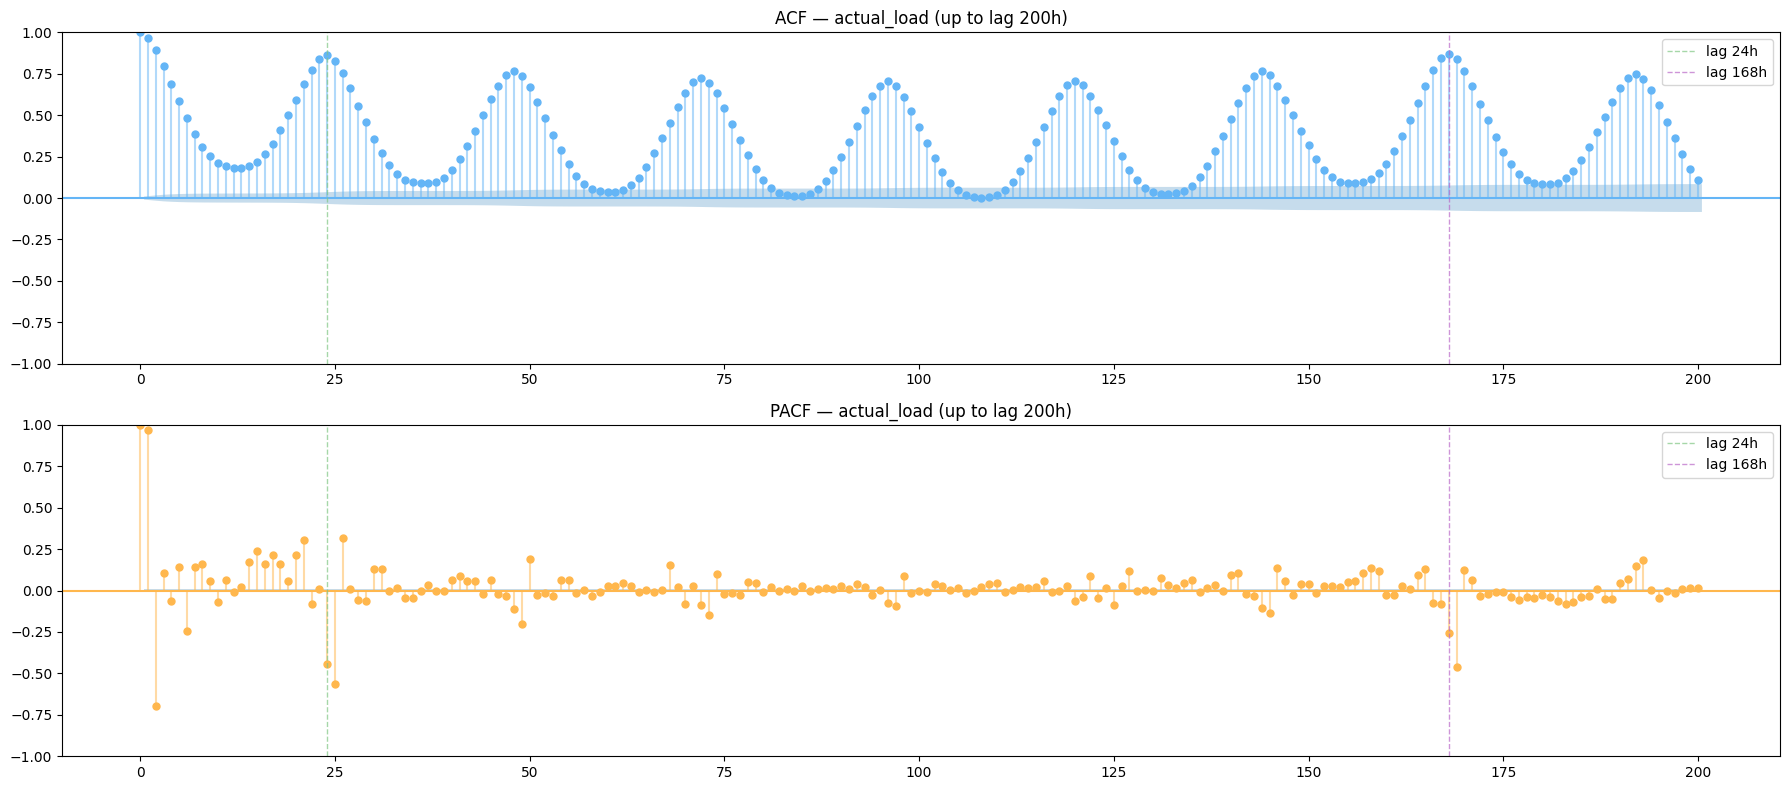

In [422]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
plot_acf(TRAIN['actual_load'].dropna(),  lags=200, ax=axes[0],
         color=C_BLUE, vlines_kwargs={'colors': C_BLUE, 'alpha': 0.5})
plot_pacf(TRAIN['actual_load'].dropna(), lags=200, ax=axes[1], method='ywm',
          color=C_ORANGE, vlines_kwargs={'colors': C_ORANGE, 'alpha': 0.5})
axes[0].set_title('ACF — actual_load (up to lag 200h)')
axes[1].set_title('PACF — actual_load (up to lag 200h)')
for ax in axes:
    ax.axvline(24,  color=C_GREEN,  ls='--', lw=1, alpha=0.7, label='lag 24h')
    ax.axvline(168, color=C_PURPLE, ls='--', lw=1, alpha=0.7, label='lag 168h')
    ax.legend()
plt.tight_layout()
plt.show()

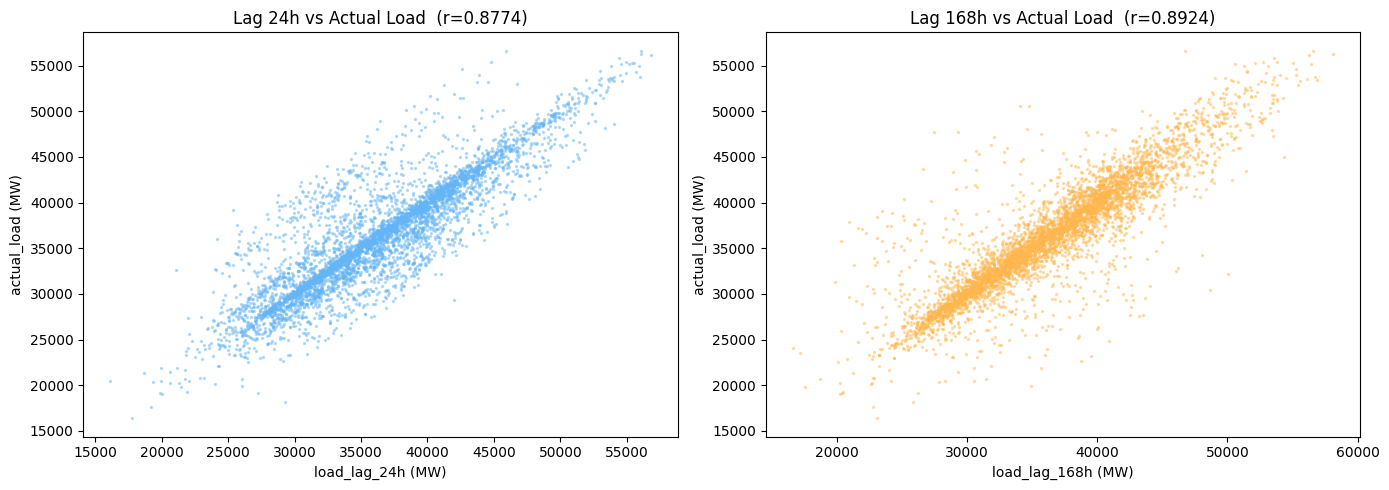

In [423]:
# Lag feature scatter: lag-24 and lag-168 vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.dropna(subset=['load_lag_24h', 'load_lag_168h']).sample(5000, random_state=0)

for ax, lag_col, color, label in [
    (axes[0], 'load_lag_24h',  C_BLUE,   'Lag 24h'),
    (axes[1], 'load_lag_168h', C_ORANGE, 'Lag 168h'),
]:
    ax.scatter(sample[lag_col], sample['actual_load'], s=2, alpha=0.4, color=color)
    r, _ = stats.pearsonr(sample[lag_col], sample['actual_load'])
    ax.set_title(f'{label} vs Actual Load  (r={r:.4f})')
    ax.set_xlabel(f'{lag_col} (MW)')
    ax.set_ylabel('actual_load (MW)')

plt.tight_layout()
plt.show()

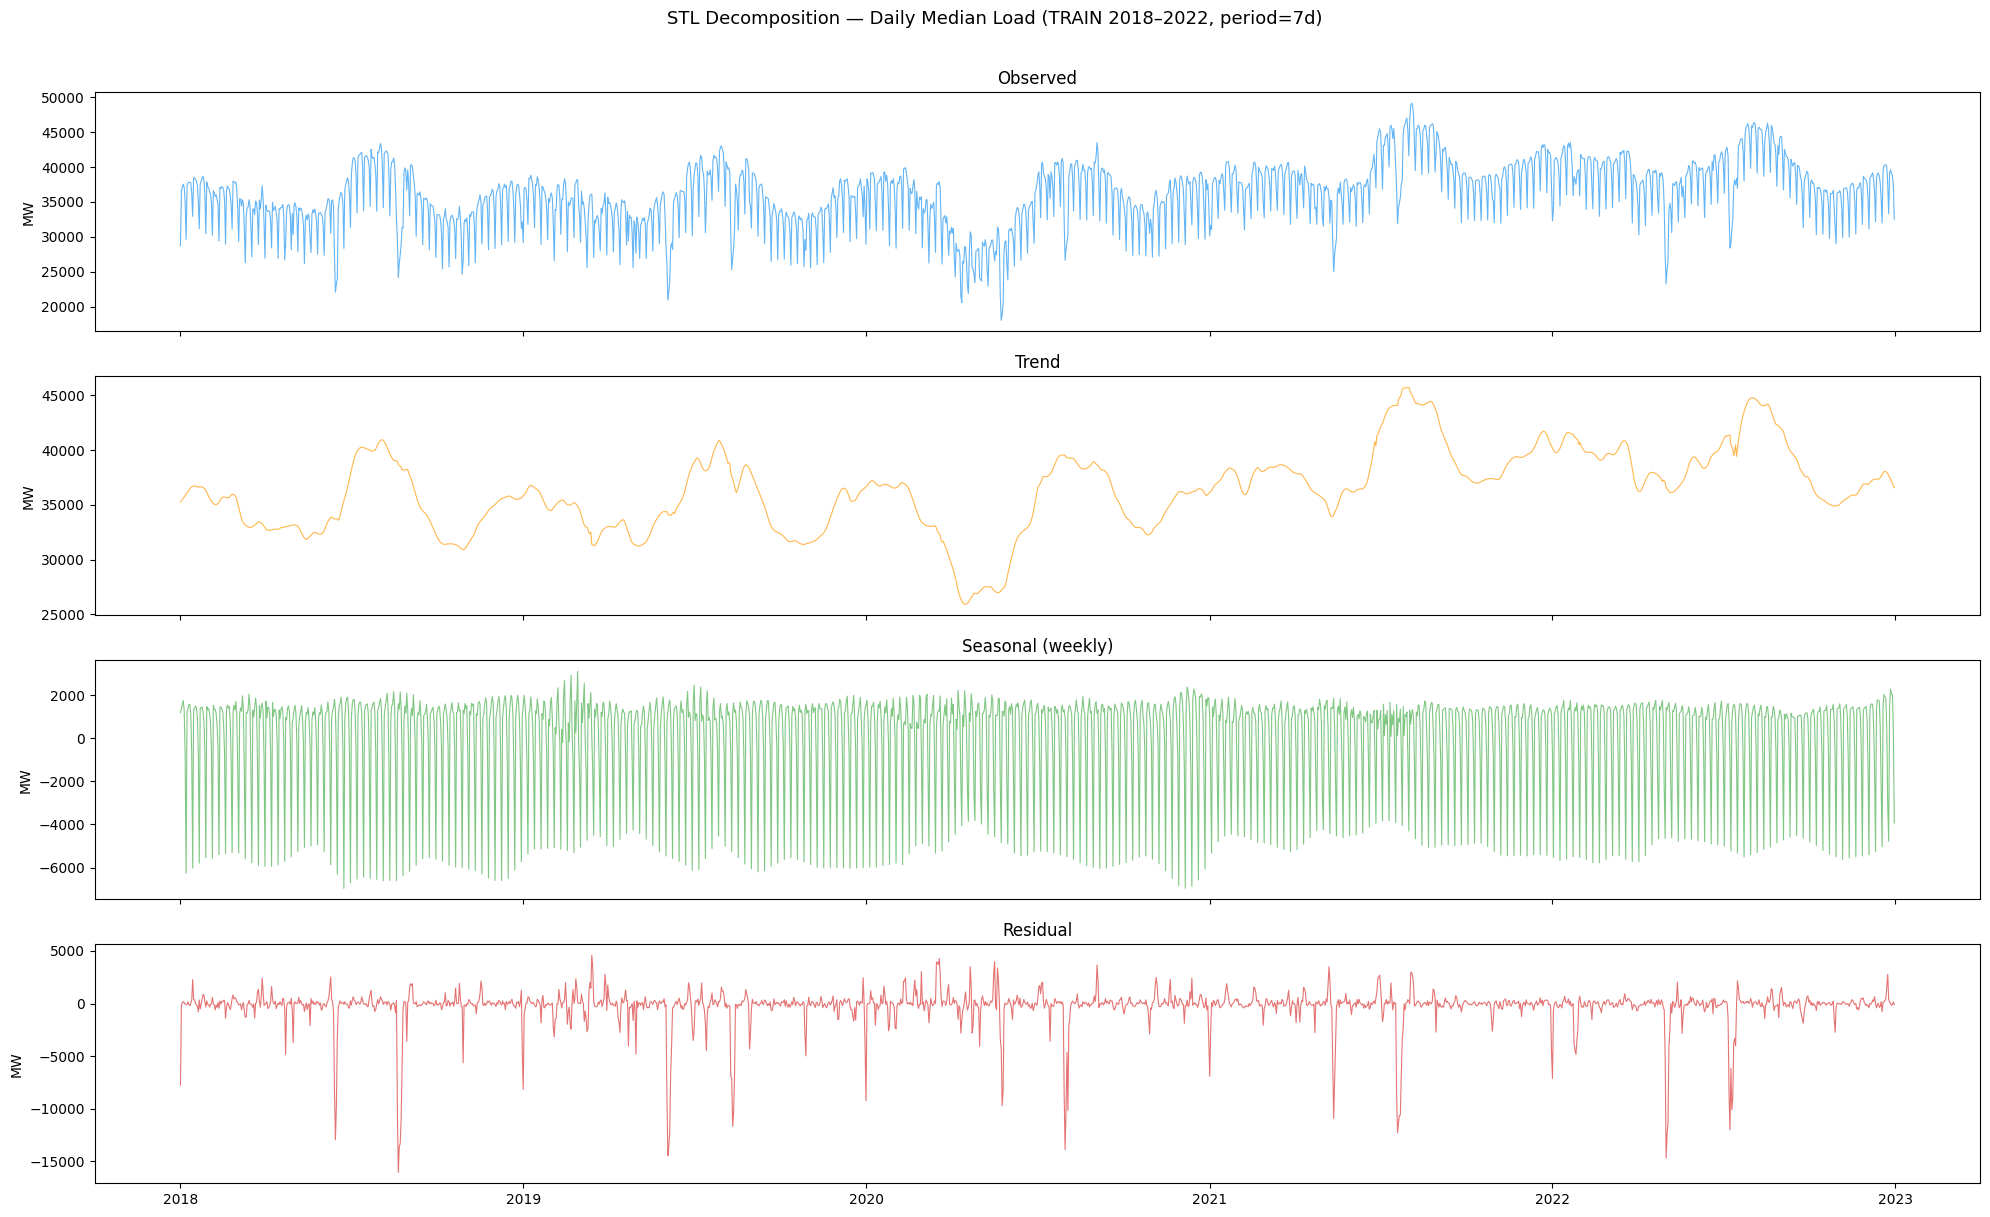

Residual variance as % of total: 16.3%


In [424]:
# STL decomposition (daily aggregation for speed)
daily_load = TRAIN['actual_load'].resample('D').median().dropna()
stl = STL(daily_load, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(20, 12), sharex=True)
components = [daily_load, stl.trend, stl.seasonal, stl.resid]
titles      = ['Observed', 'Trend', 'Seasonal (weekly)', 'Residual']
colors      = [C_BLUE, C_ORANGE, C_GREEN, C_RED]

for ax, comp, title, color in zip(axes, components, titles, colors):
    ax.plot(comp.index, comp.values, color=color, lw=0.8)
    ax.set_title(title)
    ax.set_ylabel('MW')

fig.suptitle('STL Decomposition — Daily Median Load (TRAIN 2018–2022, period=7d)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

resid_var_pct = stl.resid.var() / daily_load.var() * 100
print(f'Residual variance as % of total: {resid_var_pct:.1f}%')

---
## 11. Data Quality Audit

In [425]:
print('=== Missing value audit ===')
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
audit = pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct.round(4)})
print(audit[audit['missing_n'] > 0].to_string() if audit['missing_n'].any() else 'No missing values.')

=== Missing value audit ===
No missing values.


In [426]:
# Check temporal continuity
expected_idx = pd.date_range(df.index[0], df.index[-1], freq='h', tz='UTC')
missing_ts   = expected_idx.difference(df.index)
duplicate_ts = df.index[df.index.duplicated()]

print(f'Expected hourly timestamps : {len(expected_idx):,}')
print(f'Actual timestamps          : {len(df.index):,}')
print(f'Missing timestamps         : {len(missing_ts)}')
print(f'Duplicate timestamps       : {len(duplicate_ts)}')
if len(missing_ts):
    print(f'  First missing: {missing_ts[0]}  Last: {missing_ts[-1]}')

Expected hourly timestamps : 70,125
Actual timestamps          : 70,125
Missing timestamps         : 0
Duplicate timestamps       : 0


In [427]:
# Outlier detection on actual_load (IQR method)
Q1, Q3 = df['actual_load'].quantile(0.25), df['actual_load'].quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
outliers = df[(df['actual_load'] < lo) | (df['actual_load'] > hi)]

print(f'IQR fences (3×IQR): [{lo:,.0f}, {hi:,.0f}] MW')
print(f'Outlier rows       : {len(outliers)} ({len(outliers)/len(df)*100:.3f}%)')

if len(outliers):
    print('\nSample outliers:')
    print(outliers[['actual_load', 'temp_c', 'regime']].head(10).to_string())

IQR fences (3×IQR): [4,907, 67,188] MW
Outlier rows       : 0 (0.000%)


In [428]:
# Lag feature leakage check — ensure lag-24 is never NaN for t > 168
if 'load_lag_24h' in df.columns:
    post_warmup = df.iloc[168:]
    lag24_nan   = post_warmup['load_lag_24h'].isna().sum()
    lag168_nan  = post_warmup['load_lag_168h'].isna().sum()
    print(f'NaN in load_lag_24h  after warmup (>168h): {lag24_nan}')
    print(f'NaN in load_lag_168h after warmup (>168h): {lag168_nan}')
    print('Lag feature leakage check:', 'PASS' if lag24_nan == 0 and lag168_nan == 0 else 'FAIL — investigate')

NaN in load_lag_24h  after warmup (>168h): 0
NaN in load_lag_168h after warmup (>168h): 0
Lag feature leakage check: PASS


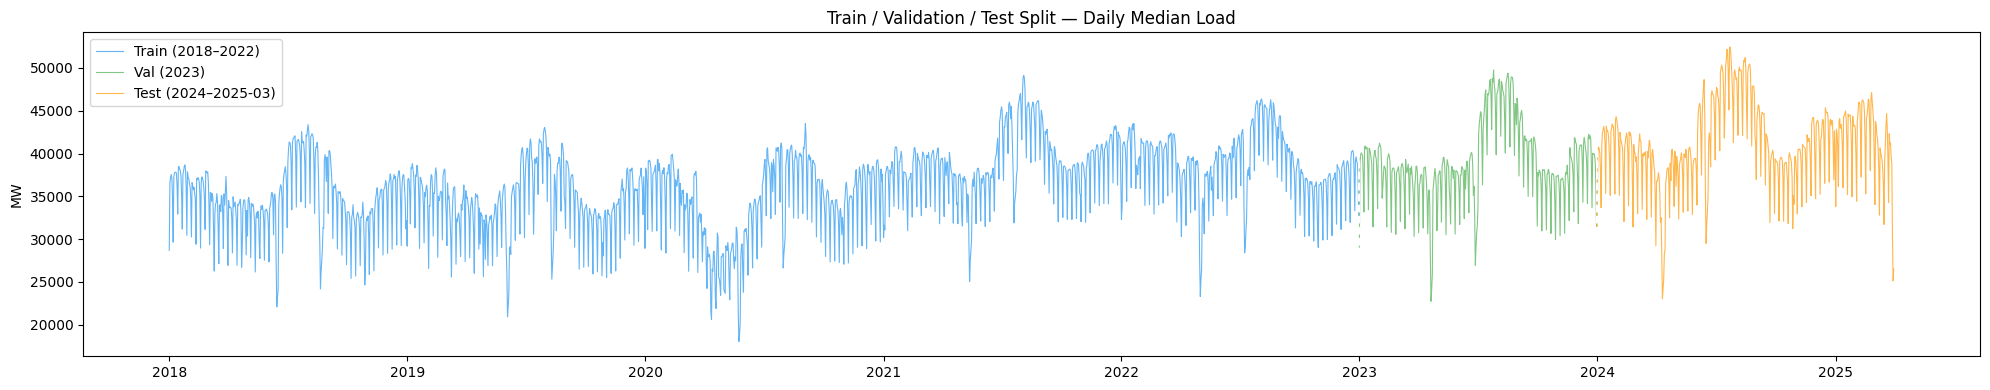

In [429]:
# Train / Val / Test boundary plot
fig, ax = plt.subplots(figsize=(20, 4))
for split_df, color, label in [
    (TRAIN, C_BLUE,   'Train (2018–2022)'),
    (VAL,   C_GREEN,  'Val (2023)'),
    (TEST,  C_ORANGE, 'Test (2024–2025-03)'),
]:
    ax.plot(split_df.resample('D')['actual_load'].median(), color=color, lw=0.8, label=label)

ax.axvline(pd.Timestamp('2023-01-01', tz='UTC'), color='white', ls='--', lw=1.5)
ax.axvline(pd.Timestamp('2024-01-01', tz='UTC'), color='white', ls='--', lw=1.5)
ax.set_title('Train / Validation / Test Split — Daily Median Load')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Summary & Modelling Implications

In [430]:
summary = {
    'Dataset rows'                        : f'{len(df):,}',
    'Date range'                          : f'{df.index[0].date()} → {df.index[-1].date()}',
    'Load range (MW)'                     : f'{df["actual_load"].min():,.0f} – {df["actual_load"].max():,.0f}',
    'Load median (MW)'                    : f'{df["actual_load"].median():,.0f}',
    'Ramadan hours (% total)'             : f'{df["is_ramadan"].sum():,} ({df["is_ramadan"].mean()*100:.1f}%)',
    'Heatwave hours (% total)'            : f'{df["is_heatwave"].sum():,} ({df["is_heatwave"].mean()*100:.1f}%)',
    'Compound hours (% total)'            : f'{(df["regime"]=="Compound").sum():,} ({(df["regime"]=="Compound").mean()*100:.1f}%)',
    'Ramadan load delta (vs Normal)'      : f'{df[df["is_ramadan"]==1]["actual_load"].median() - df[df["is_ramadan"]==0]["actual_load"].median():+,.0f} MW',
    'Heatwave load delta (vs Normal)'     : f'{df[df["regime"]=="Heatwave"]["actual_load"].median() - df[df["regime"]=="Normal"]["actual_load"].median():+,.0f} MW',
    'Lag-24h correlation with load'       : f'{df[["load_lag_24h","actual_load"]].dropna().corr().iloc[0,1]:.4f}',
    'Lag-168h correlation with load'      : f'{df[["load_lag_168h","actual_load"]].dropna().corr().iloc[0,1]:.4f}',
    'ADF stationary'                      : 'Yes (p<0.05)' if adfuller(df['actual_load'].dropna())[1] < 0.05 else 'No',
    'Missing timestamps'                  : str(len(expected_idx.difference(df.index))),
    'Missing values in final dataset'     : str(df.isnull().sum().sum()),
}

print('=' * 60)
print('  DATASET SUMMARY')
print('=' * 60)
for k, v in summary.items():
    print(f'  {k:<42}: {v}')
print('=' * 60)

  DATASET SUMMARY
  Dataset rows                              : 70,125
  Date range                                : 2018-01-01 → 2025-12-31
  Load range (MW)                           : 15,333 – 59,504
  Load median (MW)                          : 36,046
  Ramadan hours (% total)                   : 5,688 (8.1%)
  Heatwave hours (% total)                  : 3,528 (5.0%)
  Compound hours (% total)                  : 0 (0.0%)
  Ramadan load delta (vs Normal)            : -2,642 MW
  Heatwave load delta (vs Normal)           : +8,201 MW
  Lag-24h correlation with load             : 0.8779
  Lag-168h correlation with load            : 0.8894
  ADF stationary                            : Yes (p<0.05)
  Missing timestamps                        : 0
  Missing values in final dataset           : 0
